In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from src import plot, scaling, metrics, utils

CV_FOLDS=5

In [3]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    data = json.load(f)

runs = pd.DataFrame(data)

selected_obj = []
for obj in data:
    #if obj["dataset"] != "MuSiQue":
    #    continue
    #if obj["model"] != "gpt-4o":
    #    continue
    selected_obj.append(obj)

In [81]:
prompts = ["direct", "top-k", "multistep", "cot"]
scaling = ["none", "temperature", "platt", "histogram", "isotonic"]
datasets = ["HotpotQA", "2WikiMultihopQA", "MuSiQue"]
models = ["gpt-4o-mini", "gpt-4o", "Llama-3.3-70B", "DeepSeek-V3"]

In [5]:
adjust_to_title = {"none": "No Adjustment", "histogram": "Histogram Binning", "isotonic": "Isotonic Regression", "platt": "Platt Scaling", "temperature": "Temperature Scaling"}

def adjust(conf_train, conf_test, y_train, y_test, method):
    if method == "none":
        return conf_test
    elif method == "histogram":
        return scaling.histogram_scaling(conf_train, conf_test, y_train)
    elif method == "isotonic":
        return scaling.isotonic_scaling(conf_train, conf_test, y_train)
    elif method == "platt":
        return scaling.platt_scaling(conf_train, conf_test, y_train)
    elif method == "temperature":
        return scaling.temperature_scaling(conf_train, conf_test, y_train)
    else:
        raise ValueError(f"No scaling method \"{method}\" implemented")


In [6]:
from joblib import dump, load
from pathlib import Path

cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

In [7]:
def get_cache_path(prompt, dataset, model, adjust_str, fold_idx):
    fname = f"{dataset}__{model}__{prompt}__{adjust_str}__fold{fold_idx}.joblib"
    return cache_dir / fname

In [8]:
for adjust_str in ["none", "histogram", "isotonic", "platt", "temperature"]:
    for obj in selected_obj:
        csv_file = obj["csv_file"]
        prompt = obj["prompt"]
        dataset = obj["dataset"]
        model = obj["model"]

        df = pd.read_csv(runs_dir / csv_file)
        skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(df["confidence"], df["gpt_eval"])
        ):

            cache_path = get_cache_path(prompt, dataset, model, adjust_str, fold_idx)

            # ✅ LOAD if exists
            if cache_path.exists():
                cached = load(cache_path)
                adj_conf = cached["probs"]
                y_test = cached["y"]
                metrics_dict = cached["metrics"]
            else:
                # 🔥 Compute
                conf_train = df["confidence"].iloc[train_idx].values
                conf_test  = df["confidence"].iloc[test_idx].values
                y_train    = df["gpt_eval"].iloc[train_idx].values
                y_test     = df["gpt_eval"].iloc[test_idx].values

                adj_conf = adjust(conf_train, conf_test, y_train, y_test, adjust_str)

                metrics_dict = metrics.calculate_metrics(
                    y_true=y_test, y_prob=adj_conf
                )

                # ✅ SAVE
                dump({
                    "probs": adj_conf,
                    "y": y_test,
                    "metrics": metrics_dict
                }, cache_path)

In [9]:
def load_run(prompt, dataset, model, adjust_str):
    run_data = []

    for fold_idx in range(CV_FOLDS):
        cache_path = get_cache_path(prompt, dataset, model, adjust_str, fold_idx)

        if cache_path.exists():
            run_data.append(load(cache_path))
        else:
            run_data.append(None)  # or raise error

    return run_data

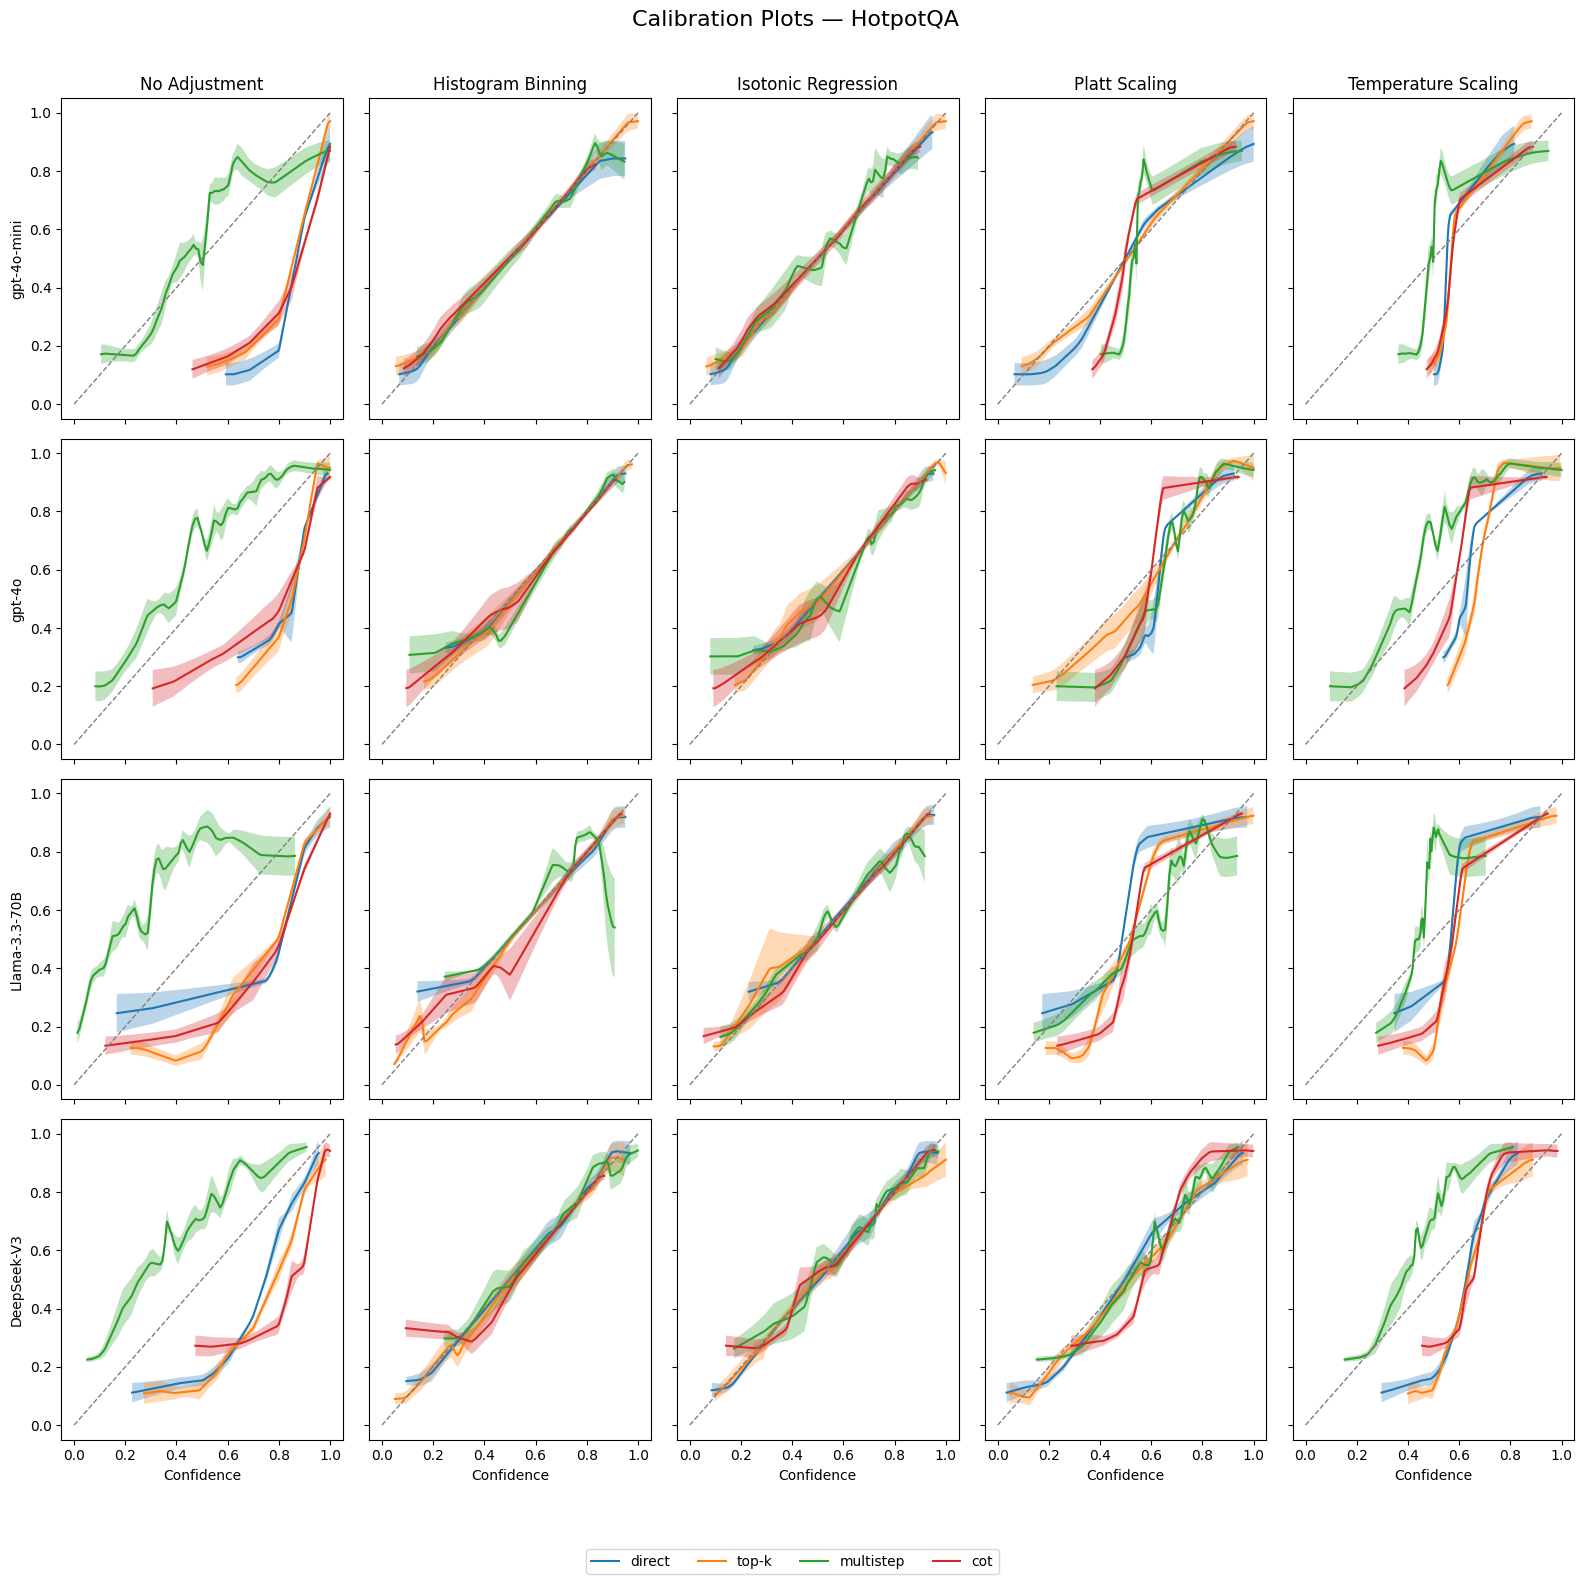

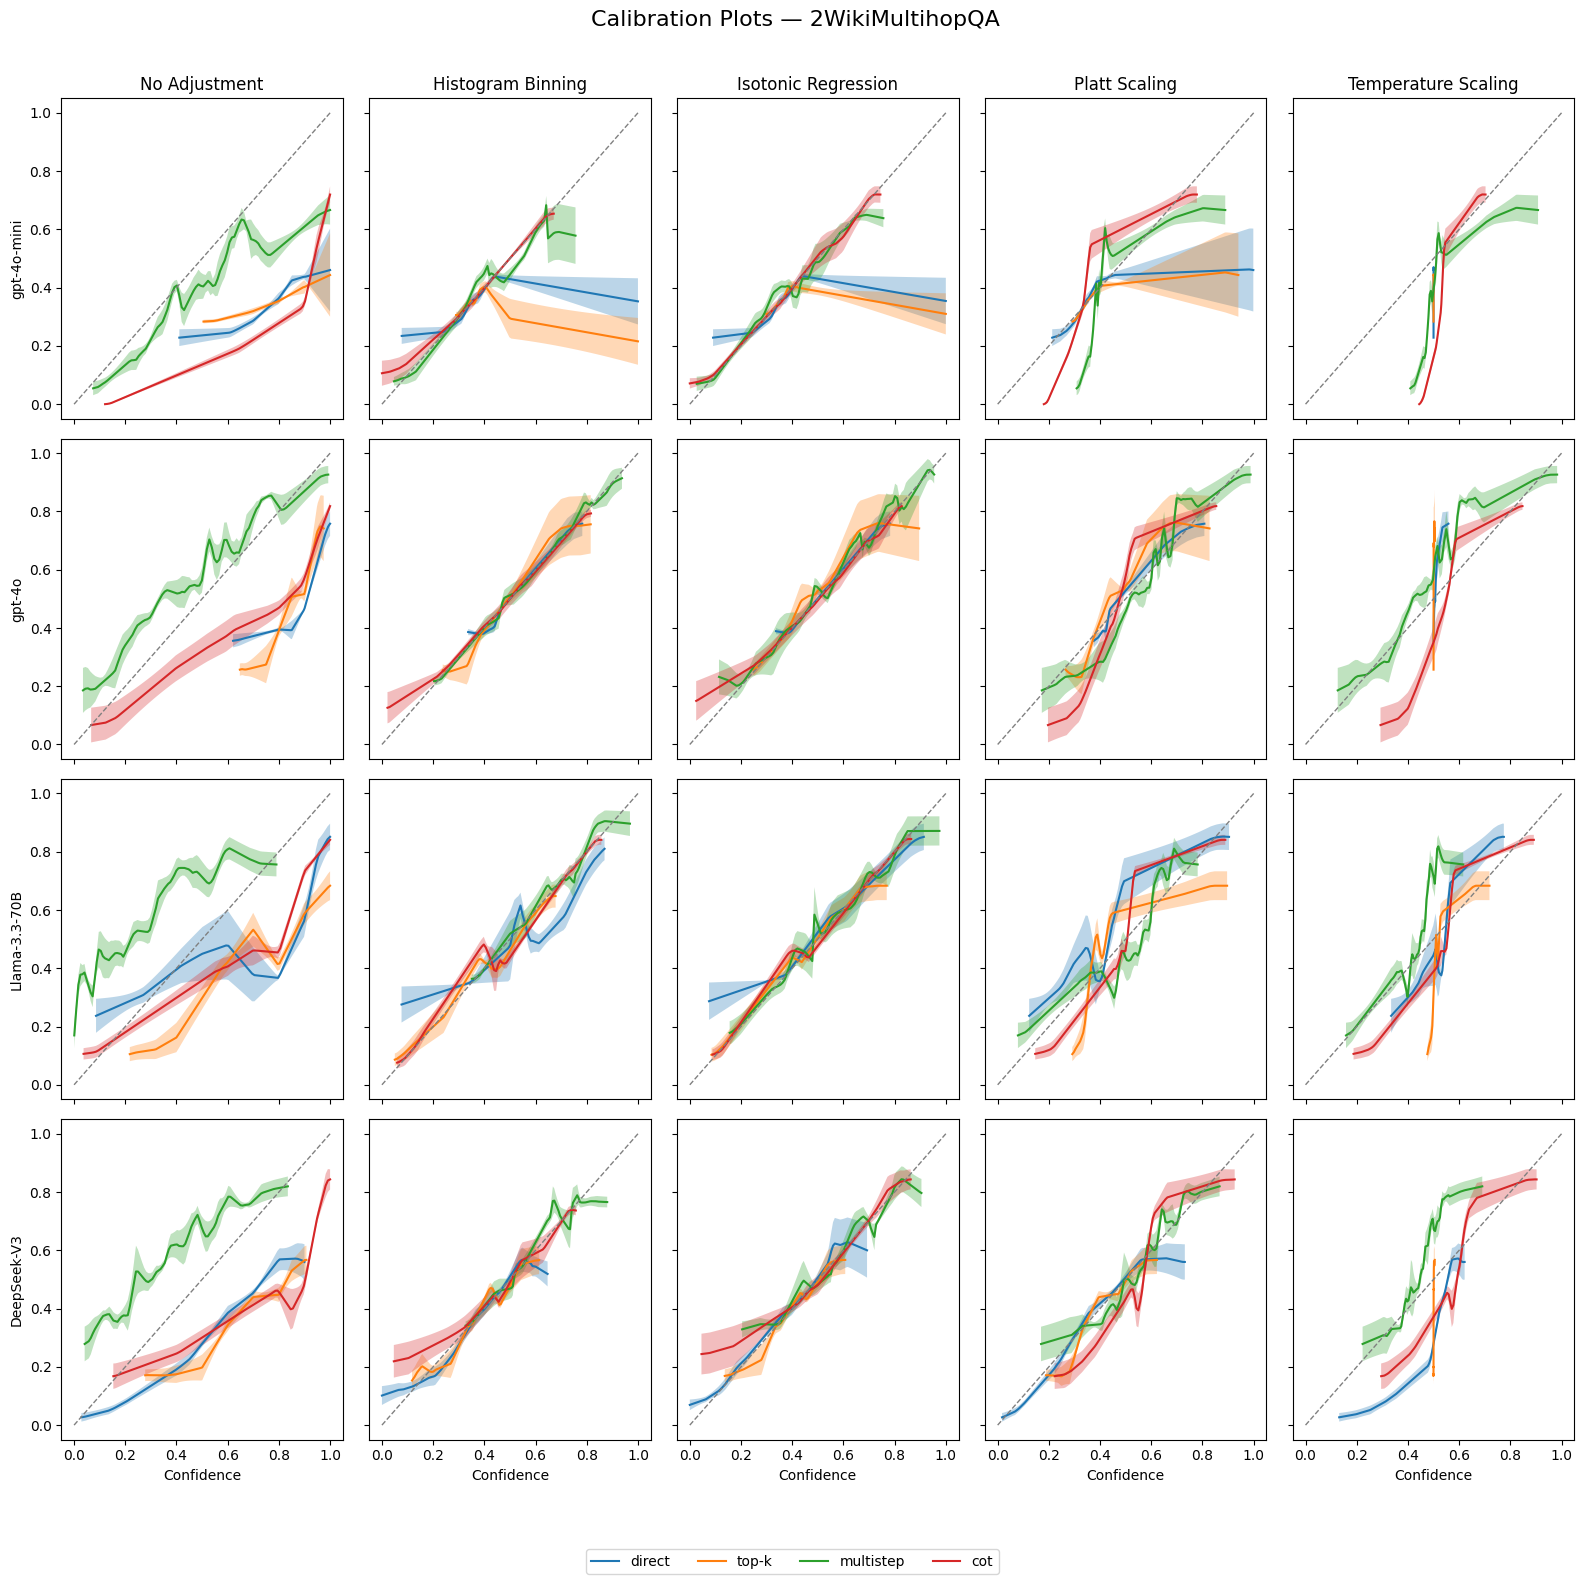

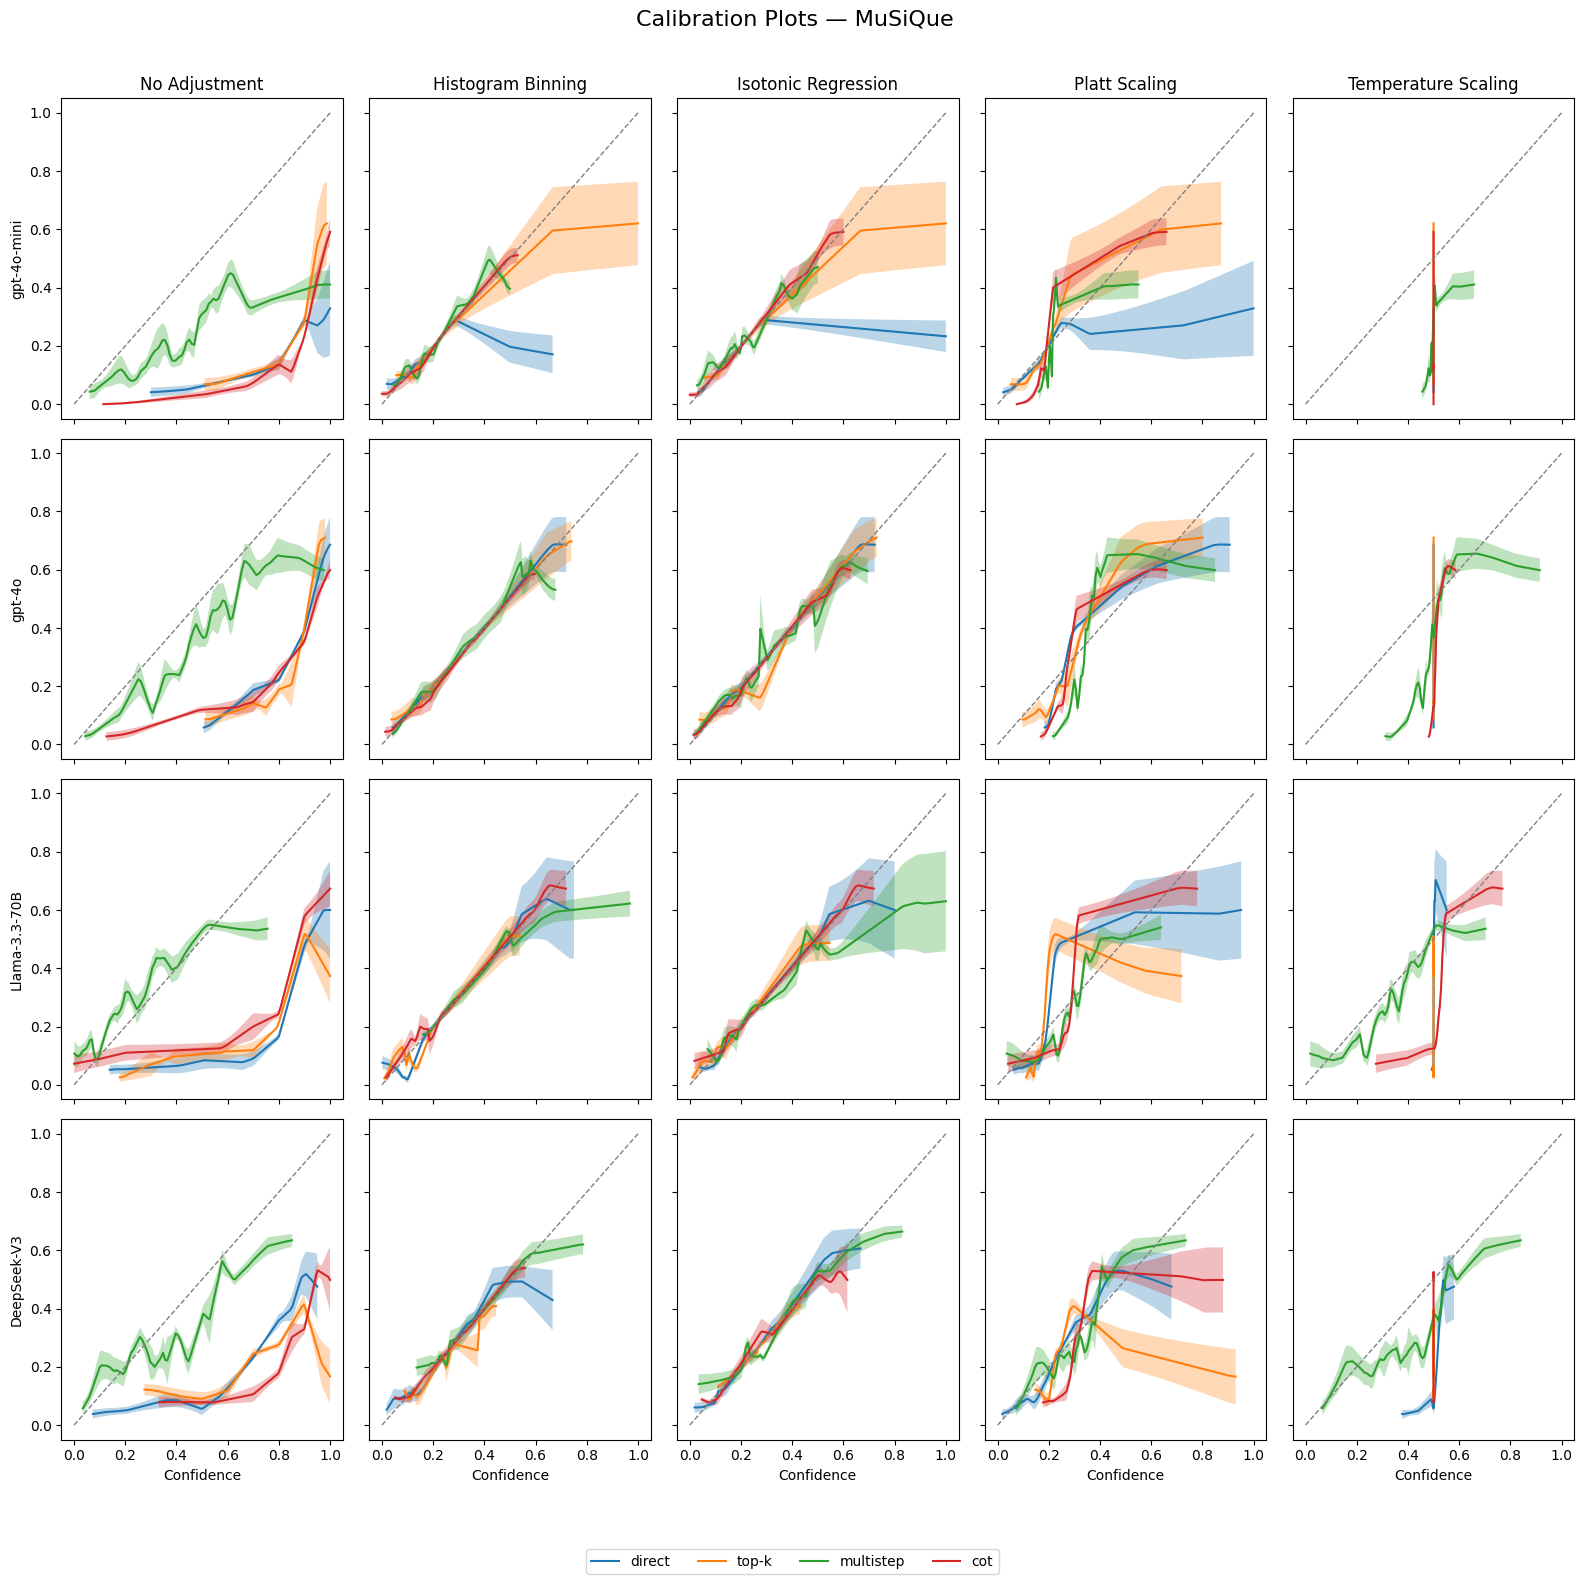

In [10]:
figsize = (16, 16)

for dataset in datasets:
    fig, axes = plt.subplots(len(models), len(scaling), figsize=figsize, sharex=True, sharey=True)

    for i, model in enumerate(models):
        for j, adjust_str in enumerate(scaling):
            ax = axes[i, j]

            for prompt in prompts:
                run_data = load_run(prompt, dataset, model, adjust_str)
                run_data = [f for f in run_data if f is not None]

                if len(run_data) == 0:
                    continue

                all_folds_confs = [f["probs"] for f in run_data]
                all_folds_y     = [f["y"]     for f in run_data]

                ax = plot.interploated_confidence_plot(
                    all_folds_y,
                    all_folds_confs,
                    n_bins=15,
                    ax=ax,
                    error_band="stderr"
                )

                ax.lines[-1].set_label(prompt)

            # Perfect calibration line
            ax.plot([0,1], [0,1], '--', color='gray', linewidth=1)

            # Titles only on top row
            if i == 0:
                ax.set_title(adjust_to_title[adjust_str])

            # Y labels only on left column
            if j == 0:
                ax.set_ylabel(model)

            # X labels only on bottom row
            if i == len(models) - 1:
                ax.set_xlabel("Confidence")

    # Global labels
    fig.suptitle(f"Calibration Plots — {dataset}", fontsize=16)

    # Single legend for all plots
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(prompts))

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()

/tmp/ipykernel_540314/450288712.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_540314/450288712.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, len(prompts), figsize=figsize, sharey=True)


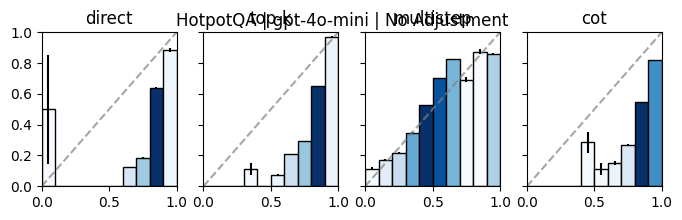

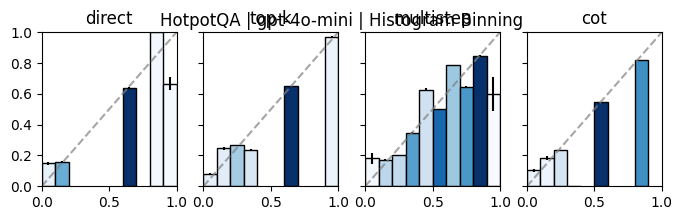

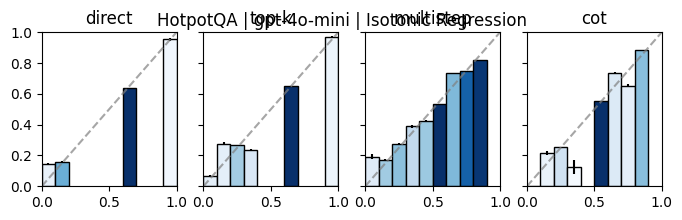

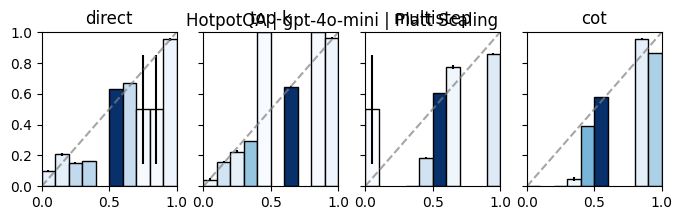

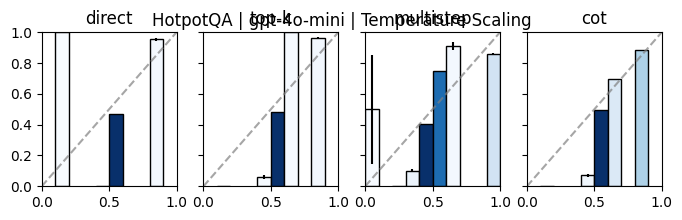

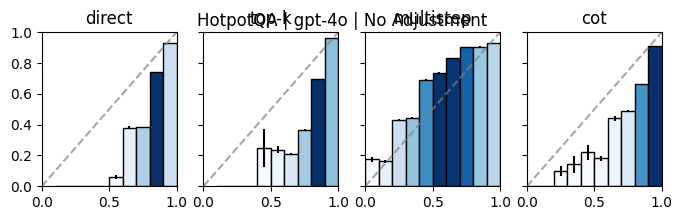

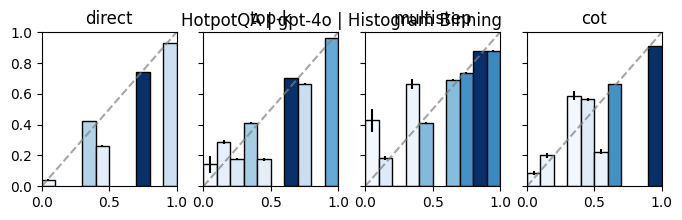

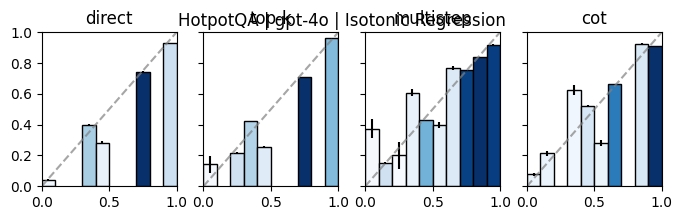

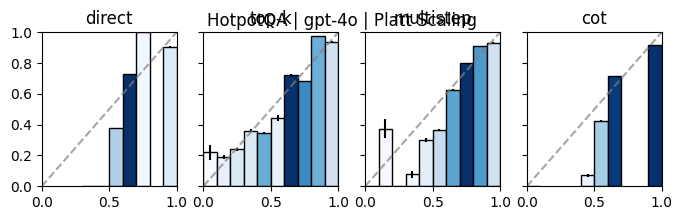

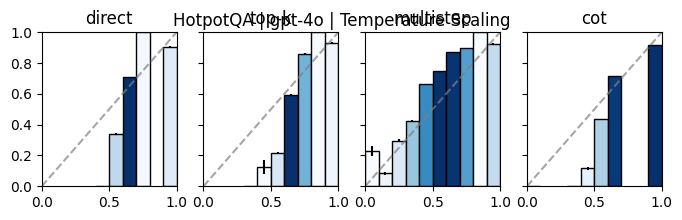

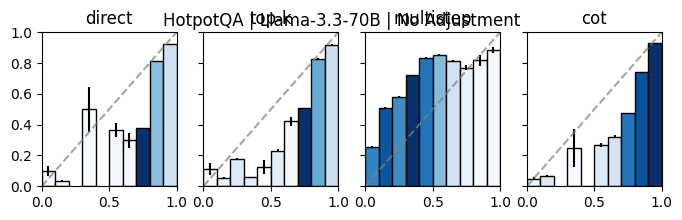

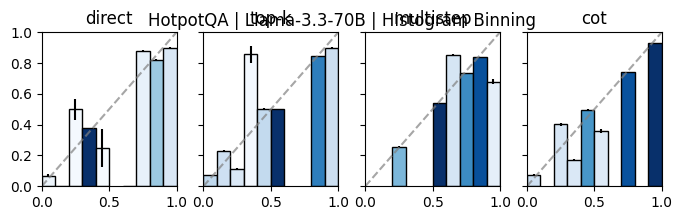

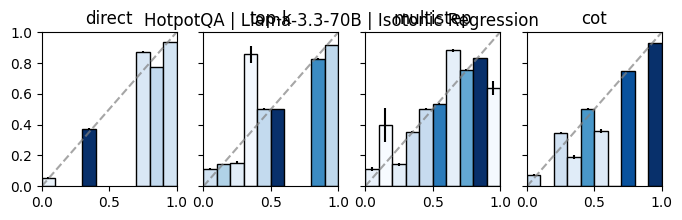

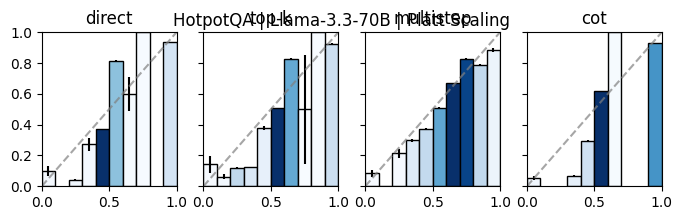

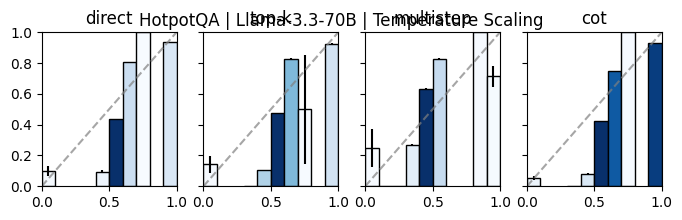

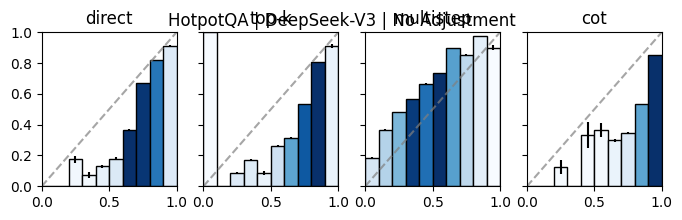

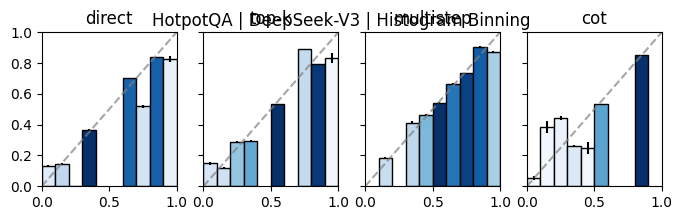

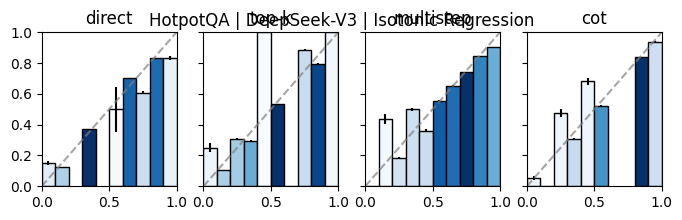

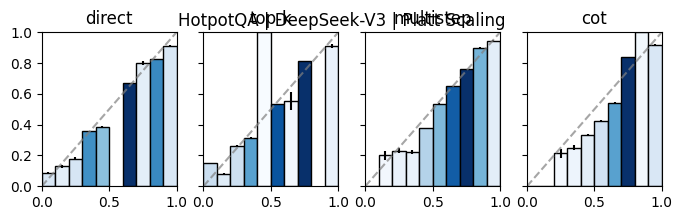

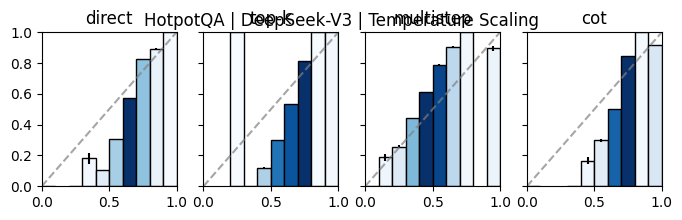

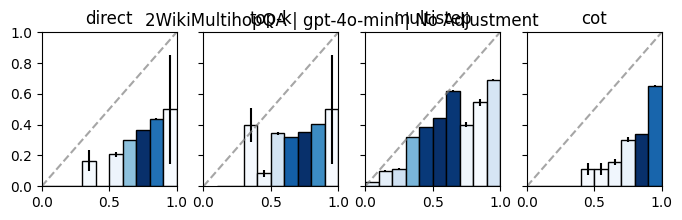

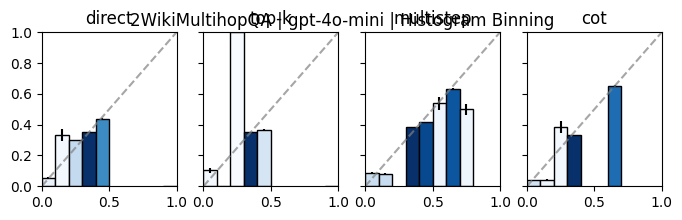

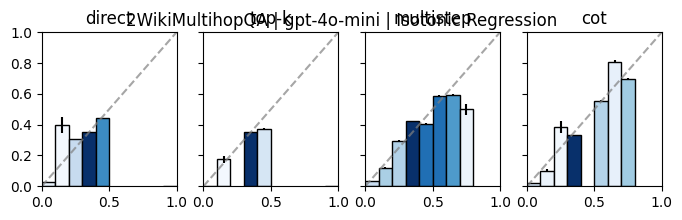

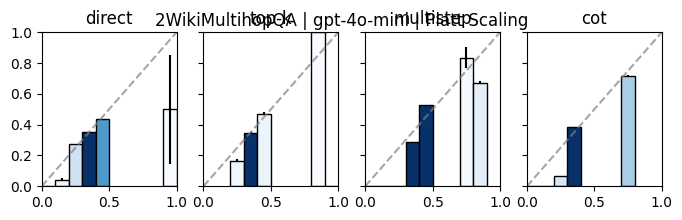

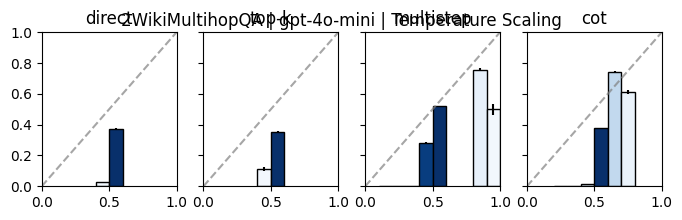

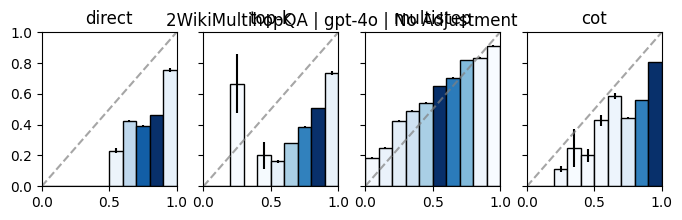

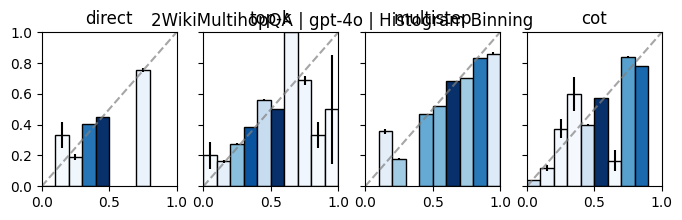

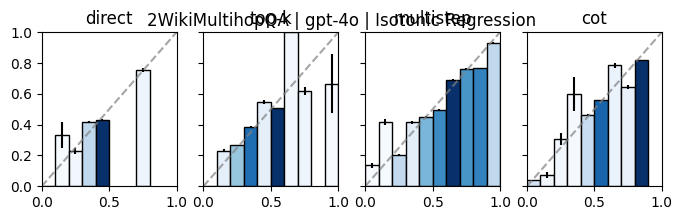

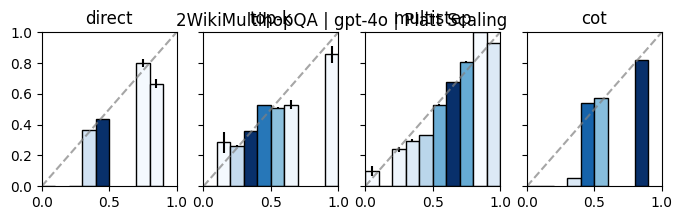

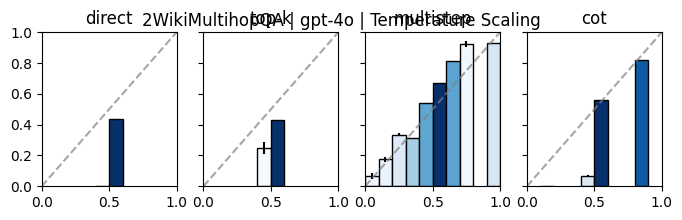

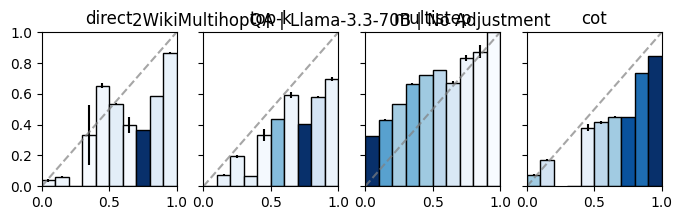

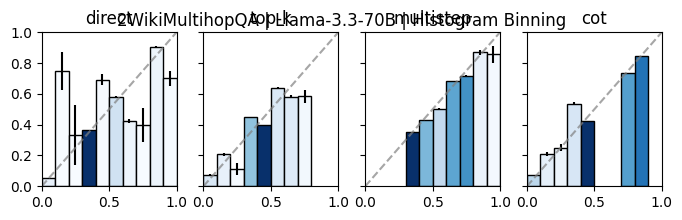

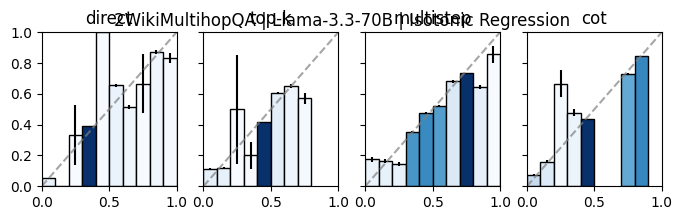

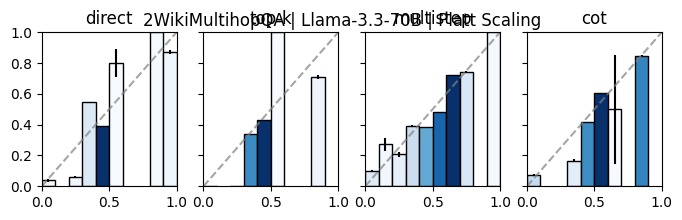

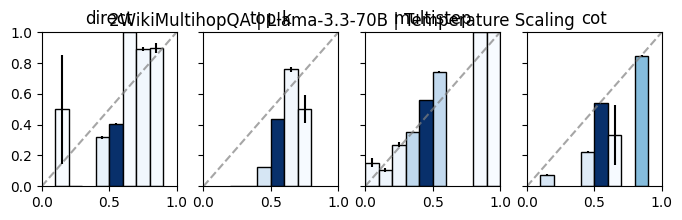

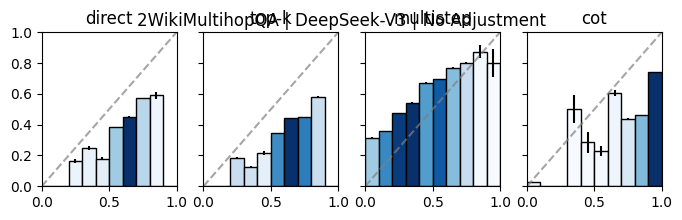

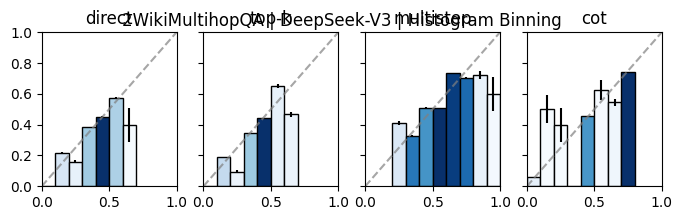

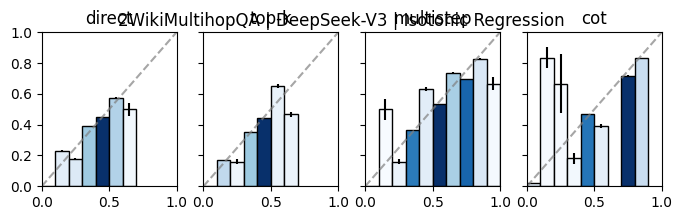

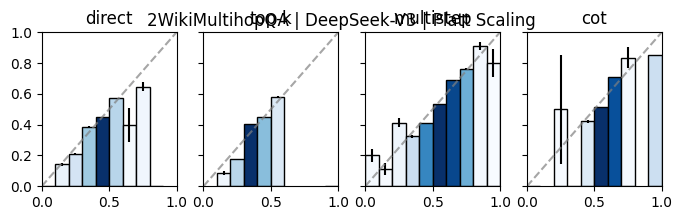

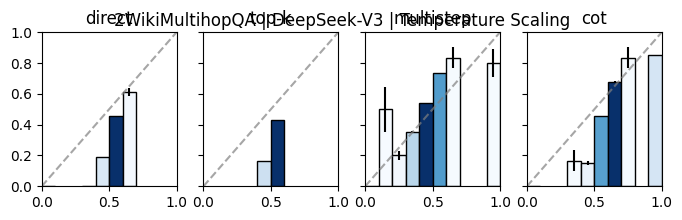

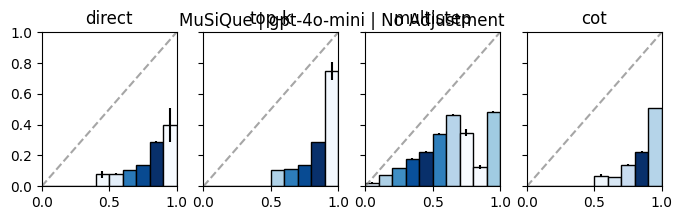

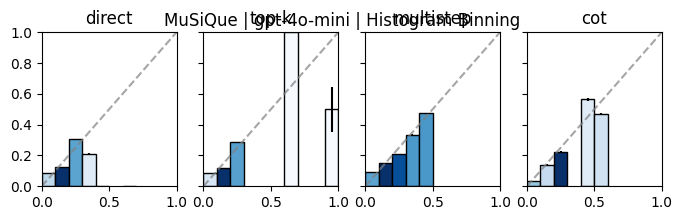

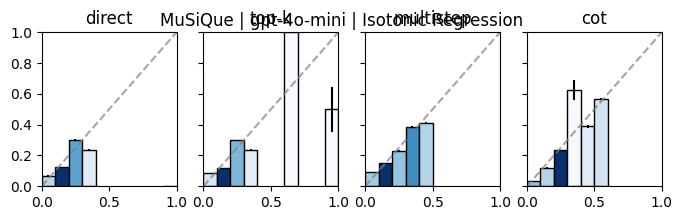

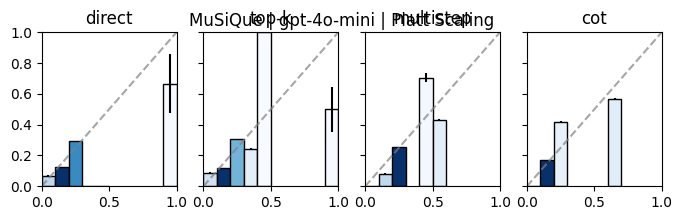

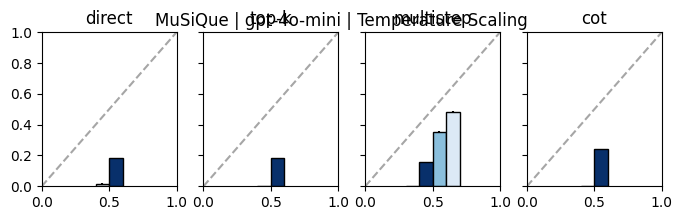

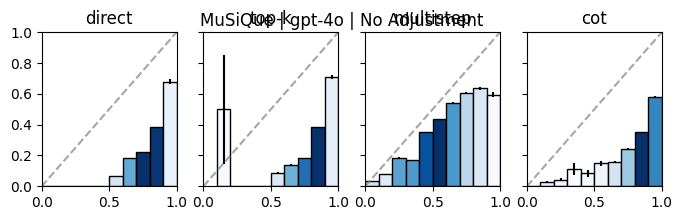

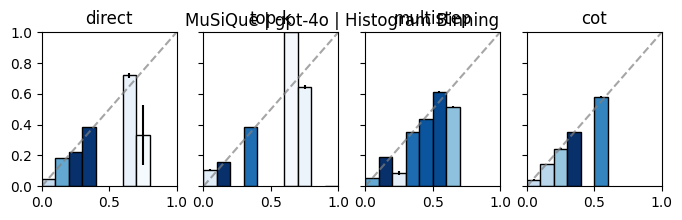

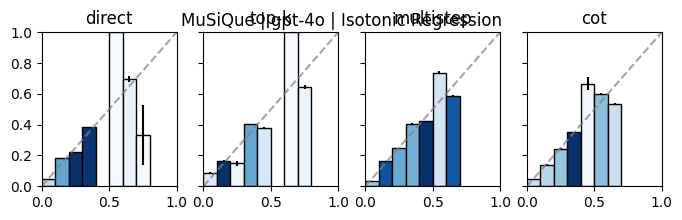

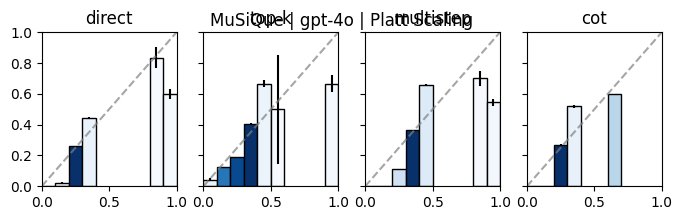

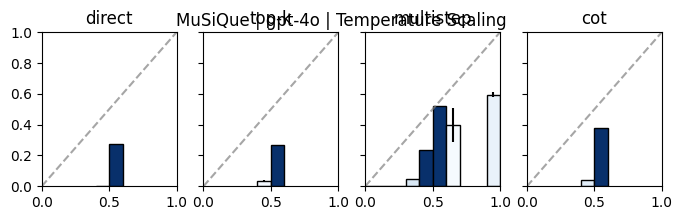

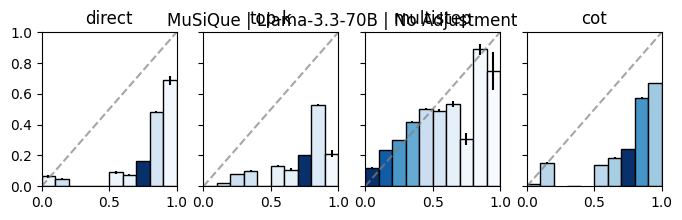

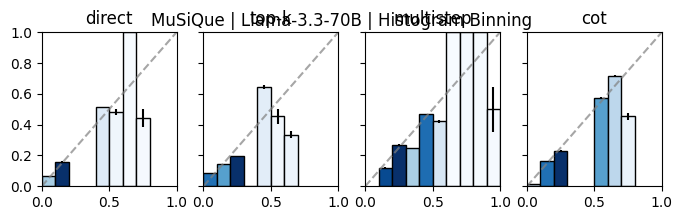

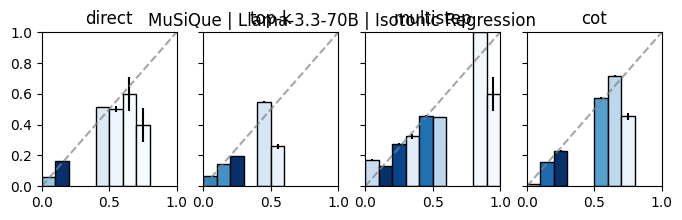

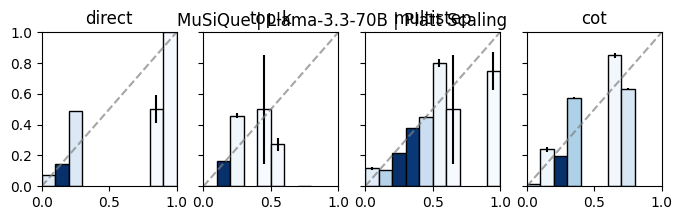

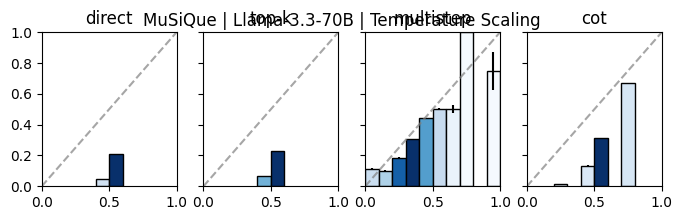

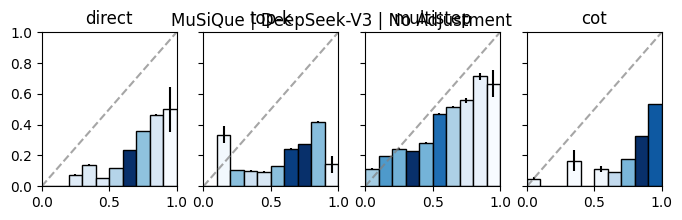

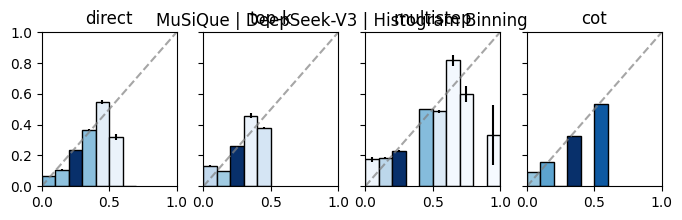

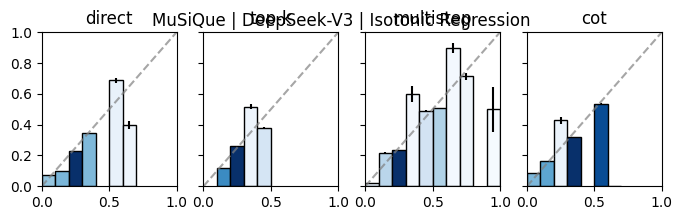

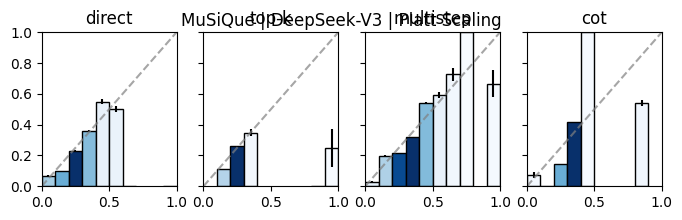

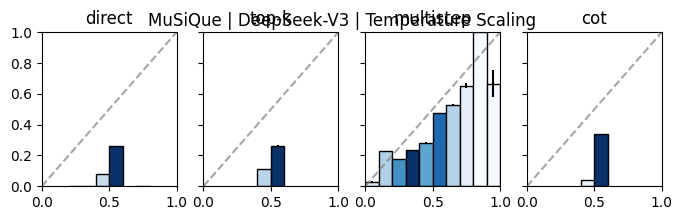

In [22]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

figsize = (8, 2)

for dataset in datasets:
    for model in models:
        for adjust_str in scaling:
            fig, axes = plt.subplots(1, len(prompts), figsize=figsize, sharey=True)

            for h, prompt in enumerate(prompts):
                ax = axes[h]  # Use the flattened sub_axes list
                
                run_data = load_run(prompt, dataset, model, adjust_str)
                run_data = [f for f in run_data if f is not None]

                if len(run_data) == 0:
                    continue

                all_folds_confs = [f["probs"] for f in run_data]
                all_folds_y     = [f["y"]     for f in run_data]

                plot.confidence_bar_plot(all_folds_y, all_folds_confs, ax=ax)
                ax.set_title(f"{prompt}")

            # Optional: set a title for the outer cell
            fig.suptitle(f"{dataset} | {model} | {adjust_to_title[adjust_str]}")
            fig.show()

In [50]:
all_metrics = []

for dataset in datasets:
    for model in models:
        for adjust_str in scaling:
            for prompt in prompts:
                data = load_run("cot", dataset, model, adjust_str)
                for d in data:
                    metrics = d["metrics"]
                    metrics.update({"dataset":dataset, "model":model, "scaling":adjust_str, "prompt":prompt})
                    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics)
                

In [105]:
metrics_df

,brier_score,roc_auc,average_precision,ece,dataset,model,scaling,prompt
0,0.315500,0.696993,0.721094,0.311000,HotpotQA,gpt-4o-mini,none,direct
1,0.311900,0.762022,0.793105,0.316500,HotpotQA,gpt-4o-mini,none,direct
2,0.301912,0.737102,0.751835,0.303750,HotpotQA,gpt-4o-mini,none,direct
3,0.300675,0.734373,0.756608,0.302000,HotpotQA,gpt-4o-mini,none,direct
4,0.301100,0.741071,0.749658,0.302000,HotpotQA,gpt-4o-mini,none,direct
...,...,...,...,...,...,...,...,...
1195,0.250004,0.745833,0.520089,0.178433,MuSiQue,DeepSeek-V3,temperature,cot
1196,0.250002,0.714641,0.481717,0.178420,MuSiQue,DeepSeek-V3,temperature,cot
1197,0.250007,0.668576,0.424967,0.178428,MuSiQue,DeepSeek-V3,temperature,cot
1198,0.250001,0.672847,0.442262,0.173393,MuSiQue,DeepSeek-V3,temperature,cot


In [128]:

agg_df = (
    metrics_df
    .groupby(["dataset", "model", "scaling", "prompt"])
    .agg(
        ece_mean=("ece", "mean"),
        ece_std=("ece", "std"),
        brier_mean=("brier_score", "mean"),
        brier_std=("brier_score", "std"),
        ap_mean=("average_precision", "mean"),
        ap_std=("average_precision", "std"),
        roc_mean=("roc_auc", "mean"),
        roc_std=("roc_auc", "std")
    ).reset_index()
)

#agg_df =agg_df[agg_df["prompt"] == "direct"]

agg_df["ece_norm"] = metrics_df.groupby("dataset")["ece"] \
    .transform(lambda x: (x - x.mean()) / x.std())

agg_df["brier_norm"] = metrics_df.groupby("dataset")["brier_score"] \
    .transform(lambda x: (x - x.mean()) / x.std())

agg_df["ap_norm"] = metrics_df.groupby("dataset")["average_precision"] \
    .transform(lambda x: (x - x.mean()) / x.std())

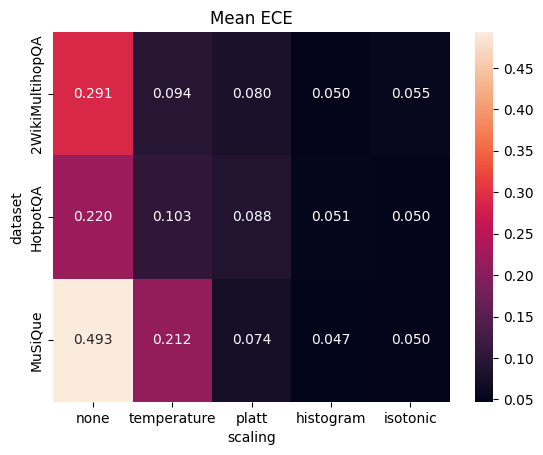

In [129]:
pivot = agg_df.pivot_table(
    index="dataset",
    columns="scaling",
    values="ece_mean"
)

pivot = pivot[scaling]

plt.figure()
sns.heatmap(pivot, annot=True, fmt=".3f")
plt.title(f"Mean ECE")
plt.show()

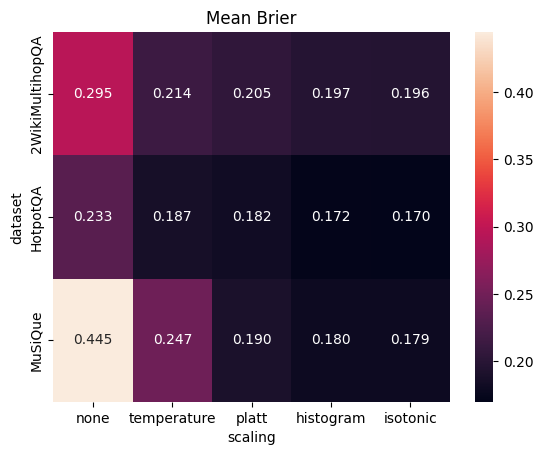

In [130]:
pivot = agg_df.pivot_table(
    index="dataset",
    columns="scaling",
    values="brier_mean"
)

pivot = pivot[scaling]

plt.figure()
sns.heatmap(pivot, annot=True, fmt=".3f")
plt.title(f"Mean Brier")
plt.show()

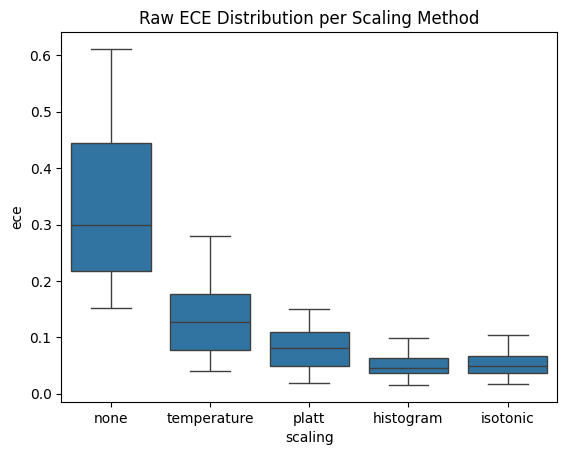

In [136]:
sns.boxplot(
    data=metrics_df,
    x="scaling",
    y="ece",
    order=scaling,
)

plt.title("Raw ECE Distribution per Scaling Method")
plt.show()

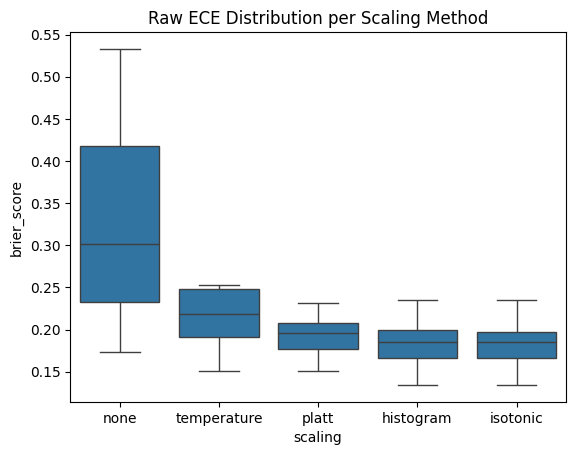

In [134]:
sns.boxplot(
    data=metrics_df,
    x="scaling",
    y="brier_score",
    order=scaling,
)

plt.title("Raw ECE Distribution per Scaling Method")
plt.show()

In [30]:
df_metrics = pd.DataFrame(all_metrics_list)

filtered_df = df_metrics[
    (df_metrics["prompt"].isin(["cot", "multistep"])) &
    (df_metrics["adjust"] == "platt")
]

table = filtered_df.pivot_table(
    index=["dataset", "prompt"],
    values=["brier_score", "ece"]
)

table.round(4)

brier_score     ece
dataset         prompt                        
2WikiMultihopQA cot             0.1959  0.0758
                multistep       0.2012  0.0695
HotpotQA        cot             0.1602  0.0824
                multistep       0.1647  0.0841
MuSiQue         cot             0.2048  0.0388
                multistep       0.2166  0.0714

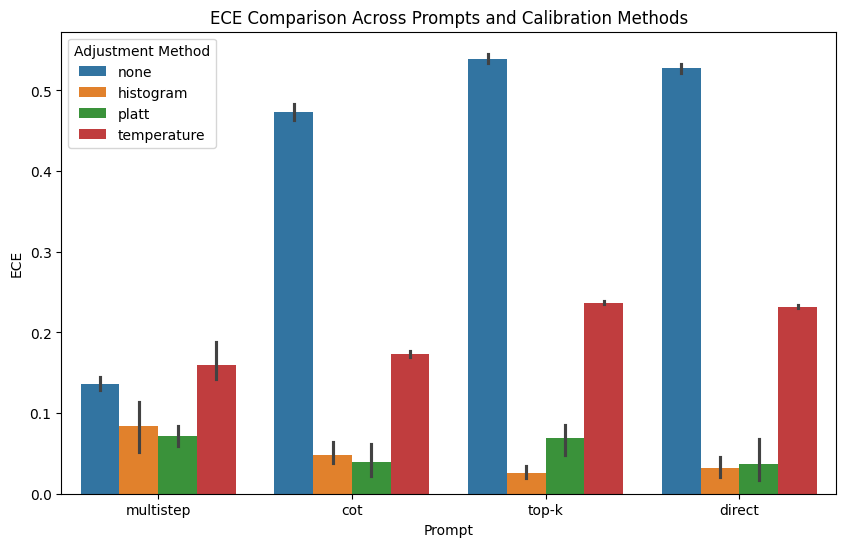

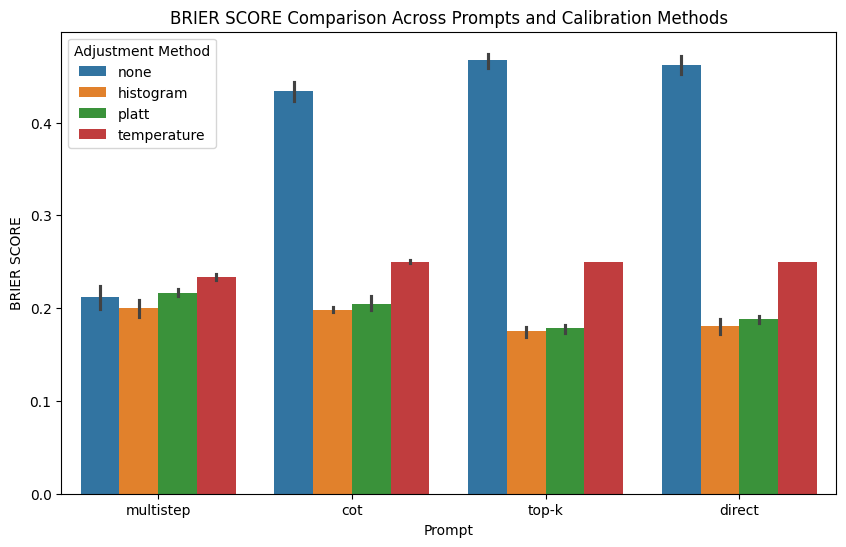

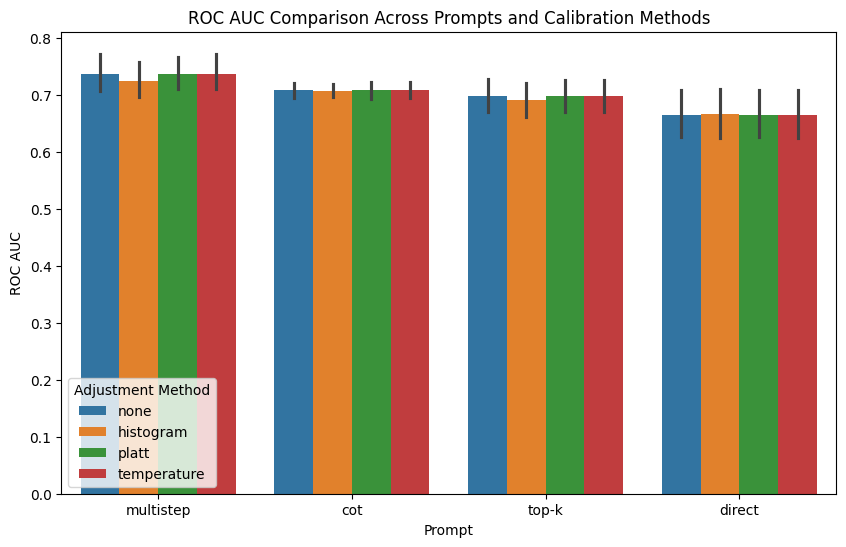

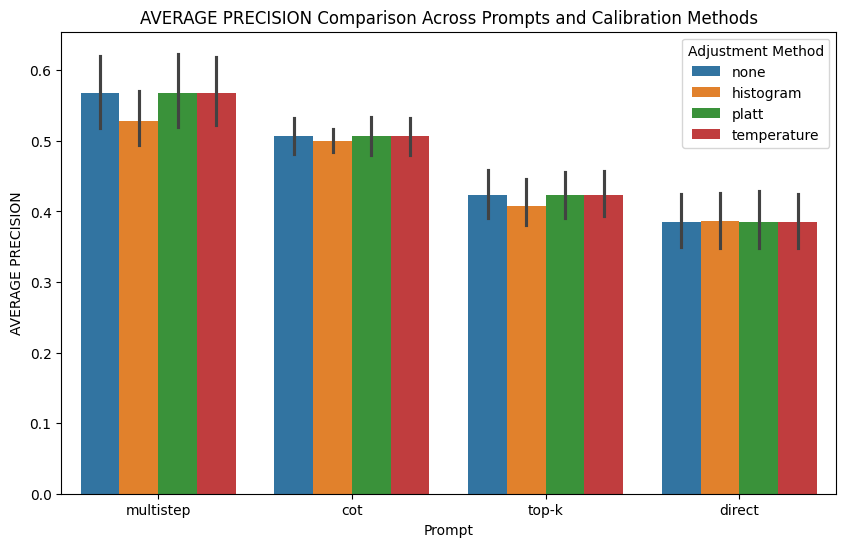

In [27]:
import seaborn as sns

dataset = "MuSiQue"

filtered_df = df_metrics[
    (df_metrics["dataset"] == dataset)
]

metrics_to_plot = ["ece","brier_score", "roc_auc", "average_precision", ]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,6))
    sns.barplot(data=filtered_df, x="prompt", y=metric, hue="adjust", dodge=True)
    plt.ylabel(metric.replace("_", " ").upper())
    plt.xlabel("Prompt")
    plt.title(f"{metric.replace('_', ' ').upper()} Comparison Across Prompts and Calibration Methods")
    plt.legend(title="Adjustment Method")
    #plt.ylim(0, 1)  # Optional, keeps scale consistent for AUC/Brier
    plt.savefig(f"{metric}_comparison.png")
    plt.show()

In [18]:
df_metrics.groupby(["prompt", "adjust"]).agg(
    ece = ("ece", "mean"),
    ece_std = ("ece", "std"),
    roc_auc = ("roc_auc", "mean"),
    roc_auc_std = ("roc_auc", "std"),
    ap = ("average_precision", "mean"),
    ap_std = ("average_precision", "std"),
    brier = ("brier_score", "mean"),
    brier_std = ("brier_score", "std")
)

ece   ece_std   roc_auc  roc_auc_std        ap  \
prompt    adjust                                                             
cot       histogram    0.047848  0.018486  0.707479     0.015771  0.499868   
          none         0.473700  0.012411  0.709481     0.018048  0.507296   
          platt        0.038802  0.025227  0.709481     0.018048  0.507296   
          temperature  0.172754  0.004989  0.709481     0.018048  0.507296   
direct    histogram    0.031300  0.016714  0.665694     0.051973  0.385901   
          none         0.527350  0.007398  0.664845     0.051696  0.385313   
          platt        0.036446  0.034891  0.664845     0.051696  0.385313   
          temperature  0.232018  0.002739  0.664845     0.051696  0.385313   
multistep histogram    0.083807  0.039963  0.723750     0.039976  0.528070   
          none         0.136570  0.009813  0.736402     0.038281  0.567496   
          platt        0.071407  0.015853  0.736326     0.038241  0.567484   
          temperature  0.159001  0.032482  0.736305     0.038310  0.567367   
top-k     histogram    0.026308  0.009325  0.691024     0.038307  0.407481   
          none         0.539550  0.007893  0.698168     0.038838  0.423291   
          platt        0.068580  0.024629  0.698168     0.038838  0.423291   
          temperature  0.237014  0.002738  0.698168     0.038838  0.423291   

                         ap_std     brier  brier_std  
prompt    adjust                                      
cot       histogram    0.021982  0.198432   0.003850  
          none         0.032986  0.433690   0.013170  
          platt        0.032986  0.204802   0.010109  
          temperature  0.032986  0.249473   0.002083  
direct    histogram    0.052063  0.180626   0.009955  
          none         0.049796  0.462208   0.012495  
          platt        0.049796  0.188224   0.005448  
          temperature  0.049796  0.250005   0.000002  
multistep histogram    0.048741  0.200110   0.012043  
          none         0.064966  0.212121   0.016666  
          platt        0.064654  0.216629   0.004817  
          temperature  0.064817  0.233208   0.003890  
top-k     histogram    0.041841  0.175299   0.006736  
          none         0.043131  0.467763   0.009865  
          platt        0.043131  0.178127   0.005995  
          temperature  0.043131  0.250004   0.000001